Cell 1: Imports & Setup

In [27]:
# GOAL:
#   Import the necessary libraries for data loading, visualization, PCA,
#   correlation checks, classification, and regression.

# WHY:
#   We need these libraries to handle a large dataset (pandas),
#   perform EDA (seaborn, matplotlib), do PCA (sklearn),
#   and build ML models (sklearn).

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


Cell 2: Load & Merge the CSV Files

In [28]:
# GOAL:
#   Merge the 7 CSV parts (~42,000 samples) into a single DataFrame.

# WHY:
#   We want a unified dataset for consistent correlation checks, PCA, and modeling.

data_dir = "../dataset/UWB-LOS-NLOS-Data-Set/dataset/"  # Adjust if your notebook is in "models/" or a different location
csv_files = glob.glob(os.path.join(data_dir, "uwb_dataset_part*.csv"))

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

uwb_df = pd.concat(df_list, ignore_index=True)

print(f"Merged {len(csv_files)} files.")
print("Total rows:", len(uwb_df))
print("Columns:", uwb_df.columns.tolist())

# Quick preview
uwb_df.head()


Merged 7 files.
Total rows: 42000
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR0', 'CIR1', 'CIR2', 'CIR3', 'CIR4', 'CIR5', 'CIR6', 'CIR7', 'CIR8', 'CIR9', 'CIR10', 'CIR11', 'CIR12', 'CIR13', 'CIR14', 'CIR15', 'CIR16', 'CIR17', 'CIR18', 'CIR19', 'CIR20', 'CIR21', 'CIR22', 'CIR23', 'CIR24', 'CIR25', 'CIR26', 'CIR27', 'CIR28', 'CIR29', 'CIR30', 'CIR31', 'CIR32', 'CIR33', 'CIR34', 'CIR35', 'CIR36', 'CIR37', 'CIR38', 'CIR39', 'CIR40', 'CIR41', 'CIR42', 'CIR43', 'CIR44', 'CIR45', 'CIR46', 'CIR47', 'CIR48', 'CIR49', 'CIR50', 'CIR51', 'CIR52', 'CIR53', 'CIR54', 'CIR55', 'CIR56', 'CIR57', 'CIR58', 'CIR59', 'CIR60', 'CIR61', 'CIR62', 'CIR63', 'CIR64', 'CIR65', 'CIR66', 'CIR67', 'CIR68', 'CIR69', 'CIR70', 'CIR71', 'CIR72', 'CIR73', 'CIR74', 'CIR75', 'CIR76', 'CIR77', 'CIR78', 'CIR79', 'CIR80', 'CIR81', 'CIR82', 'CIR83', 'CIR84', 'CIR85', 'CIR86', 'CIR87', 'CIR88', 'CIR8

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


Cell 3: Basic Inspection & Data Cleaning

In [29]:
# GOAL:
#   Inspect the dataset shape, descriptive stats, and handle any missing or duplicate data.

# WHY:
#   Ensuring data integrity is critical before correlation checks or PCA.

print("Data shape:", uwb_df.shape)

# Descriptive stats (limit columns shown if you have 1000+ columns)
with pd.option_context('display.max_columns', 20):
    print("\nDescriptive Stats (some columns may be truncated):\n", uwb_df.describe())

# Check missing values
missing_counts = uwb_df.isnull().sum()
missing_counts_nonzero = missing_counts[missing_counts > 0]
print("\nMissing values (non-zero):\n", missing_counts_nonzero)

# Example cleaning: drop rows with missing
if not missing_counts_nonzero.empty:
    uwb_df.dropna(inplace=True)
    print("Data shape after dropping rows with missing values:", uwb_df.shape)

# Optional: check duplicates
uwb_df.drop_duplicates(inplace=True)
print("Data shape after removing duplicates:", uwb_df.shape)


Data shape: (42000, 1031)

Descriptive Stats (some columns may be truncated):
                NLOS         RANGE        FP_IDX       FP_AMP1       FP_AMP2  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000      3.831519    745.654167   8127.521905  11425.259524   
std        0.500006      2.355976      4.505024   5393.330697   6235.434769   
min        0.000000      0.000000    707.000000      7.000000     63.000000   
25%        0.000000      1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000      3.480000    746.000000   7140.000000  12318.000000   
75%        1.000000      5.420000    748.000000  12273.000000  17310.000000   
max        1.000000     28.020000    848.000000  20572.000000  20624.000000   

            FP_AMP3   STDEV_NOISE       CIR_PWR     MAX_NOISE       RXPACC  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.00000   
mean    9738.106048     72.284571   9789.690214   131

Cell 4: Correlation Check Among the 13 Core Features

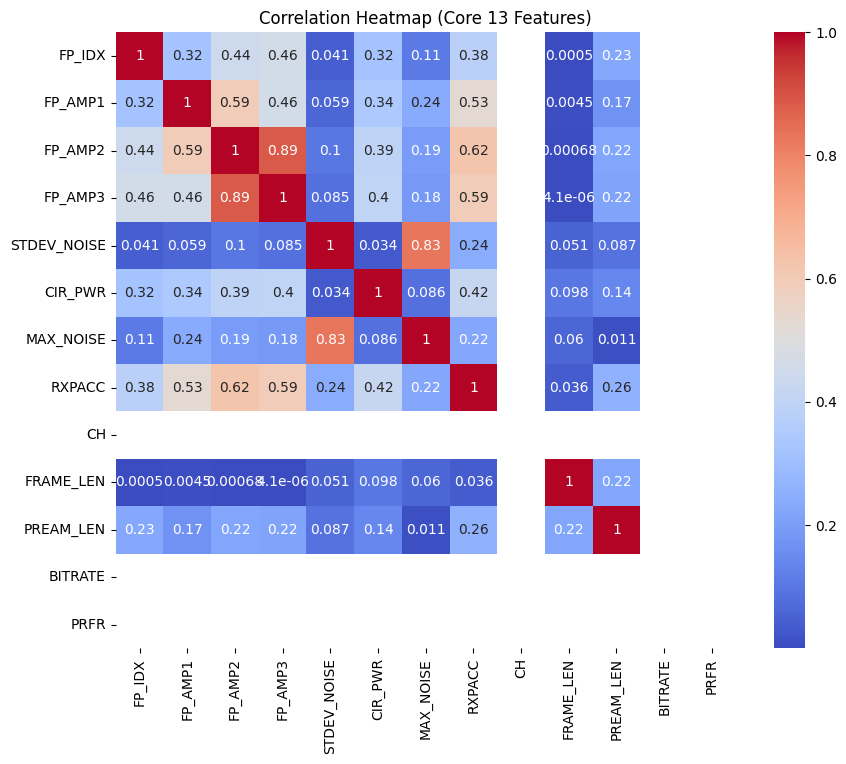

In [30]:
# GOAL:
#   Identify and optionally remove highly correlated core features
#   among these 13 columns (excluding NLOS and RANGE).

# WHY:
#   Redundant features can be dropped if correlation is above a threshold
#   (e.g., 0.80), preventing them from skewing modeling.

core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3", 
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"
]

# 1. Correlation matrix for these 13
corr_core = uwb_df[core_features].corr().abs()

# 2. Plot heatmap (may be large but let's do it)
plt.figure(figsize=(10,8))
sns.heatmap(corr_core, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Core 13 Features)")
plt.show()

# Reason:
#   This heatmap visually identifies pairs of features that are highly correlated.
#   If correlation > threshold (e.g., 0.80), we remove one to reduce redundancy.


Cell 5: Checking Unique Values & Data Types for CH, BITRATE, PRFR

In [31]:
# GOAL:
#   Inspect the unique values, data types, and descriptive stats of CH, BITRATE, PRFR.

# WHY:
#   If these columns are constant or have almost no variation, they provide no predictive power
#   and won't correlate with anything. Also, we confirm they are numeric.

print("Unique CH values:", uwb_df["CH"].unique())
print("Unique BITRATE values:", uwb_df["BITRATE"].unique())
print("Unique PRFR values:", uwb_df["PRFR"].unique())

print("\nData Types:\n", uwb_df[["CH", "BITRATE", "PRFR"]].dtypes)
print("\nDescriptive Stats:\n", uwb_df[["CH", "BITRATE", "PRFR"]].describe())

# Reason:
#   If any column shows a single unique value or zero std, it's effectively constant.
#   Such columns can be dropped. If they're non-numeric, we must convert or drop them
#   before correlation or modeling.


Unique CH values: [2.]
Unique BITRATE values: [110.]
Unique PRFR values: [64.]

Data Types:
 CH         float64
BITRATE    float64
PRFR       float64
dtype: object

Descriptive Stats:
             CH  BITRATE     PRFR
count  42000.0  42000.0  42000.0
mean       2.0    110.0     64.0
std        0.0      0.0      0.0
min        2.0    110.0     64.0
25%        2.0    110.0     64.0
50%        2.0    110.0     64.0
75%        2.0    110.0     64.0
max        2.0    110.0     64.0


Cell 6: Correlation with RANGE for MAX_NOISE vs. STDEV_NOISE

In [32]:
# GOAL:
#   Check which of MAX_NOISE or STDEV_NOISE correlates more strongly (in absolute terms)
#   with the regression target RANGE.

# WHY:
#   If two features are correlated with each other, we only keep the one that better
#   explains RANGE for regression tasks.

corr_with_range = uwb_df[["MAX_NOISE", "STDEV_NOISE", "RANGE"]].corr()
print(corr_with_range["RANGE"])

# Reason:
#   The output shows correlation with RANGE:
#   - If |MAX_NOISE| > |STDEV_NOISE|, keep MAX_NOISE (drop STDEV_NOISE).
#   - If the opposite, keep STDEV_NOISE.
#   This approach picks the more predictive feature for range estimation.


MAX_NOISE     -0.260065
STDEV_NOISE    0.089544
RANGE          1.000000
Name: RANGE, dtype: float64


Cell 7: Correlation with RANGE for FP_AMP2 vs. FP_AMP3

In [33]:
# GOAL:
#   Compare how strongly FP_AMP2 and FP_AMP3 each correlate with RANGE
#   to decide which one to keep if they're highly correlated.

# WHY:
#   If FP_AMP2 and FP_AMP3 are redundant, we keep the one that shows
#   stronger correlation (in absolute value) with the target RANGE.

corr_with_range_amp = uwb_df[["FP_AMP2", "FP_AMP3", "RANGE"]].corr()
print(corr_with_range_amp["RANGE"])

# Reason:
#   - If |FP_AMP2| > |FP_AMP3|, keep FP_AMP2 (drop FP_AMP3).
#   - If |FP_AMP3| > |FP_AMP2|, keep FP_AMP3.
#   This data-driven choice helps ensure the better explanatory feature remains.


FP_AMP2   -0.479689
FP_AMP3   -0.459521
RANGE      1.000000
Name: RANGE, dtype: float64


Cell 8: Remove Redundant & Correlated Features

Dropped features: ['CH', 'BITRATE', 'PRFR', 'STDEV_NOISE', 'FP_AMP3']
Remaining core features: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN']
Number of remaining core features: 8


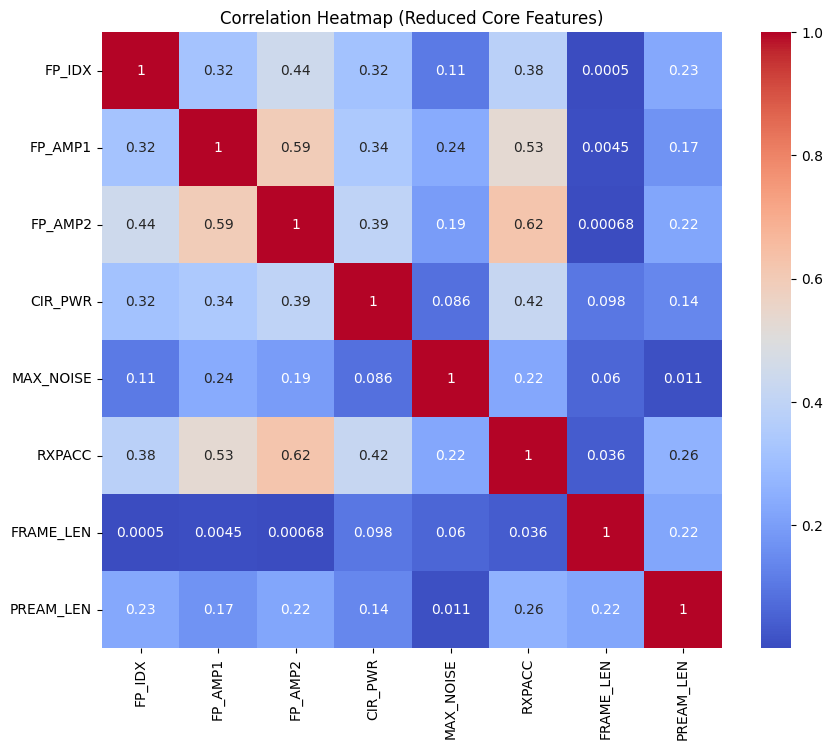

In [34]:
# GOAL:
#   Remove the identified 5 features from the core feature list, show how many remain,
#   then re-plot the correlation heatmap on the reduced set.

# WHY:
#   We want to ensure we've successfully removed redundant/constant features,
#   and verify that the remaining features have acceptable correlation levels.

# 1. Define the features to drop
features_to_drop = ["CH", "BITRATE", "PRFR", "STDEV_NOISE", "FP_AMP3"]

# 2. Remove them from your core feature list
final_core_features = [f for f in core_features if f not in features_to_drop]

print("Dropped features:", features_to_drop)
print("Remaining core features:", final_core_features)
print("Number of remaining core features:", len(final_core_features))

# 3. Re-check correlation on the remaining features
reduced_corr = uwb_df[final_core_features].corr().abs()

# 4. Plot the updated heatmap
plt.figure(figsize=(10,8))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Reduced Core Features)")
plt.show()


Cell 9: Load and Normalize CIR Data

In [35]:
# GOAL:
#   Load the full set of CIR features (CIR0..CIR1015) plus RXPACC from multiple CSV files,
#   merge them into one DataFrame, and normalize the CIR columns by dividing by RXPACC.

# WHY:
#   The dataset's instructions recommend dividing CIR values by RXPACC (the number of
#   received preamble symbols) to obtain a per-preamble-pulse measure. This ensures
#   consistent CIR scaling across different samples that might have different RXPACC counts.

cir_columns = [f'CIR{i}' for i in range(1016)]

cir_df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(data_dir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        oneFileDF = pd.read_csv(filename, usecols=cir_columns + ['RXPACC'])
        if first > 0:
            first = 0
            cir_df = oneFileDF
        else:
            cir_df = pd.concat([cir_df, oneFileDF], ignore_index=True)

# Normalize the CIR columns by dividing each row's CIR data by its RXPACC value
cir_df[cir_columns] = cir_df[cir_columns].div(cir_df['RXPACC'], axis=0)

cir_df.head()

# Reason:
#   This step produces a single DataFrame 'cir_df' where each CIR column is normalized
#   to account for varying preamble counts, making the data ready for PCA or other analysis.


,RXPACC,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,611.0,0.211129,0.510638,0.541735,0.230769,0.261866,0.798691,0.319149,0.235679,0.194763,...,0.456628,0.749591,0.299509,0.258592,0.324059,0.142390,0.484452,0.826514,0.502455,0.000000
1,447.0,0.261745,0.364653,0.445190,0.304251,0.317673,0.407159,0.800895,0.275168,0.626398,...,0.322148,0.747204,0.648770,0.510067,0.418345,0.476510,0.451902,0.199105,0.230425,0.000000
2,723.0,0.598893,0.331950,0.322268,0.112033,0.197787,0.699862,0.164592,0.376210,0.343015,...,0.044260,0.515906,0.309820,0.240664,0.171508,0.455048,0.286307,0.132780,0.301521,0.000000
3,1024.0,0.455078,0.241211,0.397461,0.219727,0.272461,0.067383,0.383789,0.425781,0.282227,...,0.246094,0.168945,0.193359,0.156250,0.423828,0.387695,0.283203,0.151367,0.333984,0.250000
4,276.0,0.938406,0.865942,0.206522,0.068841,0.318841,0.793478,1.449275,0.547101,0.355072,...,0.557971,0.757246,0.876812,1.072464,0.315217,0.644928,1.137681,0.894928,1.057971,0.927536


Cell 10: PCA on CIR Features (Choosing 8 Components)

In [36]:
# GOAL:
#   Apply PCA to reduce the 1,016 CIR columns down to 10 principal components,
#   and compute the explained variance for each component.

# WHY:
#   Reducing dimensionality speeds up further modeling while retaining the bulk
#   of the signal variance. Choosing 10 is a common compromise between
#   interpretability and information retention.

from sklearn.decomposition import PCA

pca = PCA(n_components=8)
cir_pca = pca.fit_transform(cir_df[cir_columns])

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print('Explained variance per component:', explained_variance_ratio)
print('Cumulative explained variance:', cumulative_explained_variance)

# Reason:
#   By fitting PCA with n_components=10, we see how much variance is captured
#   in those 10 PCs. If the cumulative variance is high (e.g., >80%),
#   it indicates a good dimension reduction choice.


Explained variance per component: [0.34740558 0.22098511 0.07800827 0.05110191 0.03591536 0.02901618
 0.02661144 0.02369718]
Cumulative explained variance: [0.34740558 0.56839069 0.64639896 0.69750087 0.73341623 0.76243241
 0.78904385 0.81274103]


Cell 11: Scree Plot (Cumulative Explained Variance)

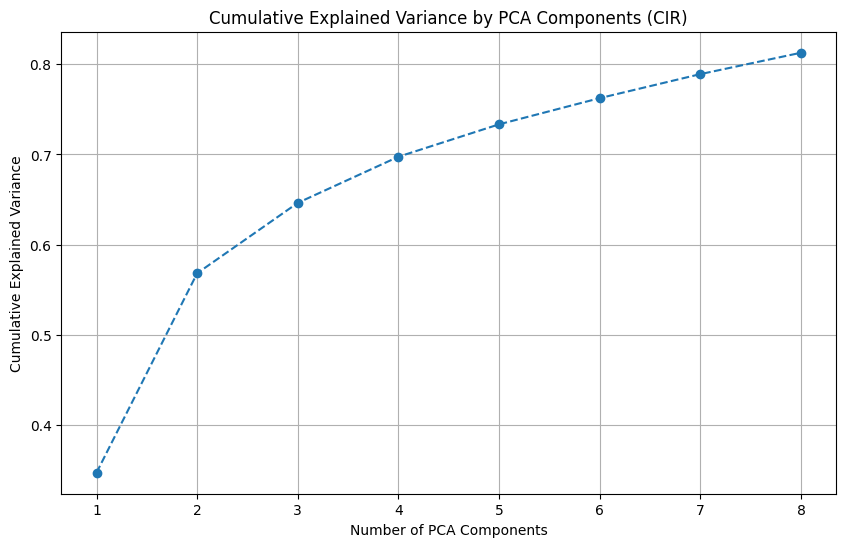

In [37]:
# GOAL:
#   Plot the cumulative explained variance of the 10 principal components
#   to visualize how quickly the variance is captured.

# WHY:
#   A scree plot helps confirm whether 10 components are sufficient
#   or if we should consider more. It's a visual way to see if
#   additional PCs beyond 10 add significant variance.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 9), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (CIR)')
plt.xticks(range(1,9))
plt.grid(True)
plt.show()

# Reason:
#   If the plot shows a plateau near 10 components, it validates our choice.
#   If the curve is still steep at 10, we might consider increasing n_components.


Cell 12: Correlation Checks (Core Features vs. NLOS & RANGE)

In [38]:
# GOAL:
#   Compute the correlation of each core feature with NLOS (0/1) and RANGE,
#   to see how strongly each feature is associated with the classification
#   and regression targets.

# WHY:
#   A higher absolute correlation suggests a stronger linear relationship.
#   This helps decide which features might be relevant.

# Reason:
#   Features with near-zero correlation to both NLOS and RANGE are often
#   prime candidates for removal, unless domain knowledge says otherwise.

# 1. Convert NLOS to numeric if needed (assuming it's already 0 or 1)
#    If it's a string or category, do: uwb_df["NLOS"] = uwb_df["NLOS"].map({"LOS":0, "NLOS":1})

core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", 
    "MAX_NOISE", "RXPACC", "FRAME_LEN", "PREAM_LEN"
    # Adjust if you have a different final set
]

# 2. Correlation with NLOS
corr_nlos = uwb_df[core_features + ["NLOS"]].corr()
print("Correlation with NLOS:\n", corr_nlos["NLOS"])

# 3. Correlation with RANGE
corr_range = uwb_df[core_features + ["RANGE"]].corr()
print("\nCorrelation with RANGE:\n", corr_range["RANGE"])


Correlation with NLOS:
 FP_IDX      -0.316978
FP_AMP1     -0.447279
FP_AMP2     -0.524905
CIR_PWR     -0.392303
MAX_NOISE   -0.198198
RXPACC       0.730690
FRAME_LEN    0.034316
PREAM_LEN    0.189658
NLOS         1.000000
Name: NLOS, dtype: float64

Correlation with RANGE:
 FP_IDX      -0.321809
FP_AMP1     -0.459196
FP_AMP2     -0.479689
CIR_PWR     -0.263718
MAX_NOISE   -0.260065
RXPACC       0.626349
FRAME_LEN   -0.048082
PREAM_LEN    0.390055
RANGE        1.000000
Name: RANGE, dtype: float64


Cell 13: Random Forest Feature Importance (Classification: NLOS)

In [39]:
# GOAL:
#   Train a quick RandomForestClassifier on the core features to see
#   which features are most important for classifying NLOS vs. LOS.

# WHY:
#   Feature importance reveals non-linear relationships that correlation might miss.
#   Higher importance means a feature significantly aids classification.

# Reason:
#   If a feature has near-zero importance, you can safely remove it.

from sklearn.ensemble import RandomForestClassifier

# 1. Prepare data for classification
X_class = uwb_df[core_features].values
y_class = uwb_df["NLOS"].values  # 0 or 1

# 2. Fit a random forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_class, y_class)

# 3. Print feature importances
importances_clf = rf_clf.feature_importances_
for feat, imp in zip(core_features, importances_clf):
    print(f"{feat} importance (NLOS classification): {imp:.5f}")


FP_IDX importance (NLOS classification): 0.04690
FP_AMP1 importance (NLOS classification): 0.11373
FP_AMP2 importance (NLOS classification): 0.16307
CIR_PWR importance (NLOS classification): 0.15585
MAX_NOISE importance (NLOS classification): 0.13003
RXPACC importance (NLOS classification): 0.37878
FRAME_LEN importance (NLOS classification): 0.00837
PREAM_LEN importance (NLOS classification): 0.00327


Cell 14: Random Forest Feature Importance (Regression: RANGE)

In [40]:
# GOAL:
#   Train a quick RandomForestRegressor on the core features to see
#   which features help predict RANGE.

# WHY:
#   Some features might be relevant for classification but not for regression, or vice versa.

# Reason:
#   If a feature is unimportant for both classification and regression,
#   it's a strong candidate for removal.

from sklearn.ensemble import RandomForestRegressor

# 1. Prepare data for regression
X_reg = uwb_df[core_features].values
y_reg = uwb_df["RANGE"].values

# 2. Fit a random forest regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_reg, y_reg)

# 3. Print feature importances
importances_reg = rf_reg.feature_importances_
for feat, imp in zip(core_features, importances_reg):
    print(f"{feat} importance (RANGE regression): {imp:.5f}")


FP_IDX importance (RANGE regression): 0.04680
FP_AMP1 importance (RANGE regression): 0.08756
FP_AMP2 importance (RANGE regression): 0.09574
CIR_PWR importance (RANGE regression): 0.13329
MAX_NOISE importance (RANGE regression): 0.09035
RXPACC importance (RANGE regression): 0.49459
FRAME_LEN importance (RANGE regression): 0.01058
PREAM_LEN importance (RANGE regression): 0.04109


Cell 15: Merged the 15 features results and saved inside prepared directory.

In [41]:
# GOAL:
#   Merge the 8-component PCA result (already computed in cir_pca) with the final core features
#   and the labels (NLOS, RANGE) into one DataFrame for classification/regression.

# WHY:
#   Having performed partial PCA on the CIR data, we want to integrate the reduced CIR features
#   (CIR_PC1..CIR_PC8) with our domain-relevant core features, excluding FRAME_LEN, and
#   include the target variables. This final DataFrame is what we'll use for modeling.

# Reason:
#   This step finalizes the partial PCA approach. We end up with a lean set of features:
#   1) pruned core features (minus FRAME_LEN),
#   2) 8 principal components for the CIR data,
#   3) labels for classification (NLOS) and regression (RANGE).

import pandas as pd

# 1. Define the final core features (excluding FRAME_LEN)
final_core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", 
    "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "PREAM_LEN"  # e.g., if you decided to keep PREAM_LEN
]

# 2. Create a DataFrame for the PCA-transformed CIR columns (8 PCs)
cir_pc_cols = [f"CIR_PC{i+1}" for i in range(8)]
df_cir_pca = pd.DataFrame(cir_pca, columns=cir_pc_cols)

# 3. Concatenate final_core_features, the 8 PCA columns, and labels
#    Assuming you have uwb_df with the full dataset, including NLOS, RANGE
label_cols = ["NLOS", "RANGE"]

final_df = pd.concat([
    uwb_df[final_core_features].reset_index(drop=True),
    df_cir_pca.reset_index(drop=True),
    uwb_df[label_cols].reset_index(drop=True)
], axis=1)

print("Final DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())
final_df.head()

# (Optional) Save the final preprocessed dataset
save_path = "../dataset/UWB-LOS-NLOS-Data-Set/prepared/final_preprocessed_8PCs.csv"
final_df.to_csv(save_path, index=False)
print(f"Final preprocessed data saved to: {save_path}")


Final DataFrame shape: (42000, 17)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']
Final preprocessed data saved to: ../dataset/UWB-LOS-NLOS-Data-Set/prepared/final_preprocessed_8PCs.csv
